### Download and unzip the dataset

In [ ]:
!wget "https://zenodo.org/records/1188976/files/Audio_Speech_Actors_01-24.zip?download=1" -O ravdess.zip
!unzip ravdess.zip -d data
!rm ravdess.zip

--2026-03-07 14:17:02--  https://zenodo.org/records/1188976/files/Audio_Speech_Actors_01-24.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 188.184.98.114, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 208468073 (199M) [application/octet-stream]
Saving to: ‘ravdess.zip’

ravdess.zip         100%[===================>] 198.81M  3.35MB/s    in 58s     

2026-03-07 14:18:01 (3.43 MB/s) - ‘ravdess.zip’ saved [208468073/208468073]

Archive:  ravdess.zip
   creating: data/Actor_01/
  inflating: data/Actor_01/03-01-01-01-01-01-01.wav  
  inflating: data/Actor_01/03-01-01-01-01-02-01.wav  
  inflating: data/Actor_01/03-01-01-01-02-01-01.wav  
  inflating: data/Actor_01/03-01-01-01-02-02-01.wav  
  inflating: data/Actor_01/03-01-02-01-01-01-01.wav  
  inflating: data/Actor_01/03-01-02-01-01-02-01.wav  
  inflating: data/Actor_01/03-01-02-01-02-01-01.wav  
  inflating: data/Ac

### Install openSMILE

In [ ]:
!pip install opensmile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.8/137.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 19.9 MB/s eta 0:00:00


### 1. Process the dataset with openSMILE using low-level descriptors AND functionals

In [ ]:
import opensmile
from pathlib import Path

# LLDs
smile_lld = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.LowLevelDescriptors
)

# Functionals
smile_func = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.Functionals
)

data_path = Path('data')
data = []
labels = []
for f in data_path.rglob('*.wav'):
    data.append(f)
    labels.append(int(f.stem[7]))

print(labels[:10])

df_func = smile_func.process_files(data)
df_lld = smile_lld.process_files(data)

df_func['label'] = labels

[5, 1, 3, 6, 6, 2, 1, 6, 1, 2]


### Standard OpenSmile output - functionals

In [ ]:
print(df_func.info())
df_func.head()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1440 entries, ('data/Actor_20/03-01-05-02-02-01-20.wav', Timedelta('0 days 00:00:00'), Timedelta('0 days 00:00:04.404416667')) to ('data/Actor_08/03-01-03-02-02-01-08.wav', Timedelta('0 days 00:00:00'), Timedelta('0 days 00:00:03.837166667'))
Data columns (total 89 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   F0semitoneFrom27.5Hz_sma3nz_amean               1440 non-null   float32
 1   F0semitoneFrom27.5Hz_sma3nz_stddevNorm          1440 non-null   float32
 2   F0semitoneFrom27.5Hz_sma3nz_percentile20.0      1440 non-null   float32
 3   F0semitoneFrom27.5Hz_sma3nz_percentile50.0      1440 non-null   float32
 4   F0semitoneFrom27.5Hz_sma3nz_percentile80.0      1440 non-null   float32
 5   F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2        1440 non-null   float32
 6   F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope     1440 

,,,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope,...,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp,label
file,start,end,,,,,,,,,,,,,,,,,,,,,
data/Actor_20/03-01-05-02-02-01-20.wav,0 days,0 days 00:00:04.404416667,46.130444,0.130940,42.014591,47.378033,50.922504,8.907913,152.696854,74.425362,103.189255,78.944054,...,0.012288,0.109010,2.050114,1.152074,0.404000,0.164024,0.44000,0.416317,-18.452406,5
data/Actor_20/03-01-01-01-02-01-20.wav,0 days,0 days 00:00:03.436770833,35.857121,0.165234,33.561092,37.775661,39.200771,5.639679,90.793571,99.845299,42.262955,9.823778,...,0.013886,0.012923,2.339181,1.483680,0.196000,0.119766,0.38000,0.439507,-49.732903,1
data/Actor_20/03-01-03-01-02-01-20.wav,0 days,0 days 00:00:03.470125,34.556477,0.122302,31.914852,35.639618,37.627640,5.712788,187.496262,100.612106,32.192039,26.380503,...,0.009377,0.006337,2.023121,0.879765,0.470000,0.110454,0.48250,0.419725,-41.981129,3
data/Actor_20/03-01-06-02-02-02-20.wav,0 days,0 days 00:00:03.903916667,52.954254,0.084719,50.629791,54.222160,55.916451,5.286659,100.564789,100.561813,82.181259,59.725975,...,0.006633,0.046136,2.313625,1.041667,0.400000,0.491325,0.43000,0.356258,-17.990276,6
data/Actor_20/03-01-06-02-01-01-20.wav,0 days,0 days 00:00:04.237562500,46.498901,0.139465,41.625568,47.506493,52.103302,10.477734,221.406052,265.135101,150.000702,129.902161,...,0.002593,0.103202,1.895735,1.678657,0.235714,0.420165,0.29625,0.307690,-20.835878,6


### Standard OpenSmile output - low-level descriptors

In [ ]:
print(df_lld.info())
df_lld.head()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 526547 entries, ('data/Actor_20/03-01-05-02-02-01-20.wav', Timedelta('0 days 00:00:00'), Timedelta('0 days 00:00:00.020000')) to ('data/Actor_08/03-01-03-02-02-01-08.wav', Timedelta('0 days 00:00:03.780000'), Timedelta('0 days 00:00:03.837166667'))
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loudness_sma3                526547 non-null  float32
 1   alphaRatio_sma3              526547 non-null  float32
 2   hammarbergIndex_sma3         526547 non-null  float32
 3   slope0-500_sma3              526547 non-null  float32
 4   slope500-1500_sma3           526547 non-null  float32
 5   spectralFlux_sma3            526547 non-null  float32
 6   mfcc1_sma3                   526547 non-null  float32
 7   mfcc2_sma3                   526547 non-null  float32
 8   mfcc3_sma3                   526547 non-null  float32
 9   mfcc4_sma3    

Loudness_sma3  \
file                                   start                  end                                     
data/Actor_20/03-01-05-02-02-01-20.wav 0 days 00:00:00        0 days 00:00:00.020000       0.001502   
                                       0 days 00:00:00.010000 0 days 00:00:00.030000       0.003416   
                                       0 days 00:00:00.020000 0 days 00:00:00.040000       0.003416   
                                       0 days 00:00:00.030000 0 days 00:00:00.050000       0.002948   
                                       0 days 00:00:00.040000 0 days 00:00:00.060000       0.001034   

                                                                                      alphaRatio_sma3  \
file                                   start                  end                                       
data/Actor_20/03-01-05-02-02-01-20.wav 0 days 00:00:00        0 days 00:00:00.020000         2.996404   
                                       0 days 00:00:00.010000 0 days 00:00:00.030000         5.860718   
                                       0 days 00:00:00.020000 0 days 00:00:00.040000         5.860718   
                                       0 days 00:00:00.030000 0 days 00:00:00.050000         2.864315   
                                       0 days 00:00:00.040000 0 days 00:00:00.060000         0.000000   

                                                                                      hammarbergIndex_sma3  \
file                                   start                  end                                            
data/Actor_20/03-01-05-02-02-01-20.wav 0 days 00:00:00        0 days 00:00:00.020000             -1.265430   
                                       0 days 00:00:00.010000 0 days 00:00:00.030000             -2.537442   
                                       0 days 00:00:00.020000 0 days 00:00:00.040000             -2.537442   
                                       0 days 00:00:00.030000 0 days 00:00:00.050000             -1.272012   
                                       0 days 00:00:00.040000 0 days 00:00:00.060000              0.000000   

                                                                                      slope0-500_sma3  \
file                                   start                  end                                       
data/Actor_20/03-01-05-02-02-01-20.wav 0 days 00:00:00        0 days 00:00:00.020000         0.120525   
                                       0 days 00:00:00.010000 0 days 00:00:00.030000         0.069040   
                                       0 days 00:00:00.020000 0 days 00:00:00.040000         0.069040   
                                       0 days 00:00:00.030000 0 days 00:00:00.050000         0.113114   
                                       0 days 00:00:00.040000 0 days 00:00:00.060000         0.164599   

                                                                                      slope500-1500_sma3  \
file                                   start                  end                                          
data/Actor_20/03-01-05-02-02-01-20.wav 0 days 00:00:00        0 days 00:00:00.020000            0.025128   
                                       0 days 00:00:00.010000 0 days 00:00:00.030000            0.024524   
                                       0 days 00:00:00.020000 0 days 00:00:00.040000            0.024524   
                                       0 days 00:00:00.030000 0 days 00:00:00.050000            0.028030   
                                       0 days 00:00:00.040000 0 days 00:00:00.060000            0.028635   

                                                                                      spectralFlux_sma3  \
file                                   start                  end                                         
data/Actor_20/03-01-05-02-02-01-20.wav 0 days 00:00:00        0 days 00:00:00.020000           0.000022   
                                       0 da

### 2. Classifying emotions using RandomForest model with 5-fold cross-validation

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

X = df_func.drop(columns=['label'])
y = df_func['label']

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=123))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')

print(f"Accuracy for each fold: {scores}")
print(f"Mean Accuracy: {scores.mean():.3f}")
print(f"Standard Deviation: {scores.std():.3f}")

Accuracy for each fold: [0.63541667 0.59375    0.58680556 0.62152778 0.61805556]
Mean Accuracy: 0.611
Standard Deviation: 0.018


### 3. Visualizations - Classification Confusion Matrix

       name  count
0   Neutral     96
1      Calm    192
2     Happy    192
3       Sad    192
4     Angry    192
5   Fearful    192
6   Disgust    192
7  Surprise    192


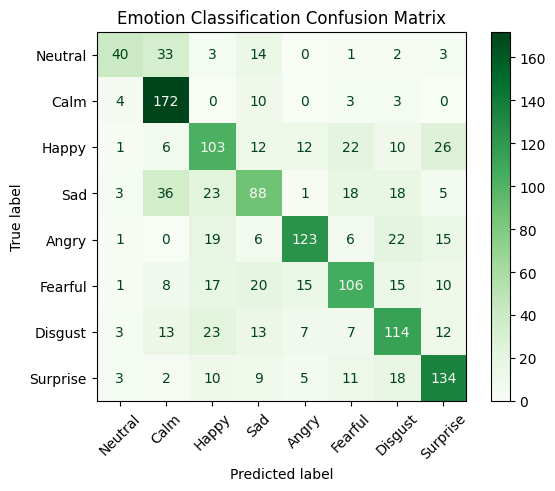

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
import pandas as pd

emotion_dict = {
    1: 'Neutral',
    2: 'Calm',
    3: 'Happy',
    4: 'Sad',
    5: 'Angry',
    6: 'Fearful',
    7: 'Disgust',
    8: 'Surprise'
}

unique_labels = np.unique(y, return_counts=True)
emotion_names = [emotion_dict[label] for label in unique_labels[0]]
print(pd.DataFrame({'name': emotion_names, 'count': unique_labels[1]}))

y_pred = cross_val_predict(pipeline, X, y, cv=cv)

ConfusionMatrixDisplay.from_predictions(
    y,
    y_pred,
    display_labels=emotion_names,
    cmap='Greens',
    xticks_rotation=45
)
plt.title('Emotion Classification Confusion Matrix')
plt.show()

### Classification Metrics

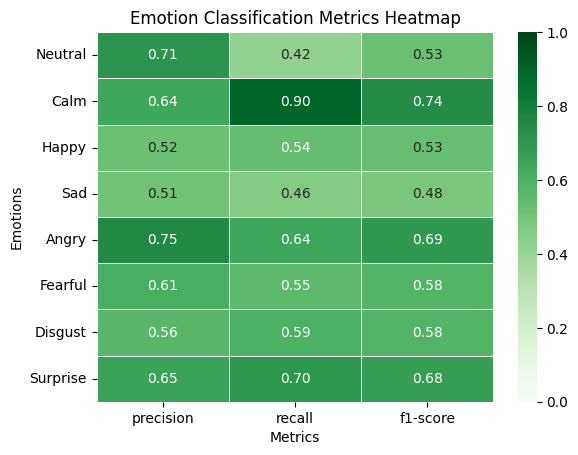

In [ ]:
from sklearn.metrics import classification_report
import seaborn as sns

report_dict = classification_report(
    y,
    y_pred,
    target_names=emotion_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
metrics_df = report_df.drop(columns=['support'])[:-3]

sns.heatmap(
    metrics_df,
    annot=True,
    cmap='Greens',
    vmin=0, vmax=1,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Emotion Classification Metrics Heatmap')
plt.xlabel('Metrics')
plt.ylabel('Emotions')
plt.show()

### Feature importance

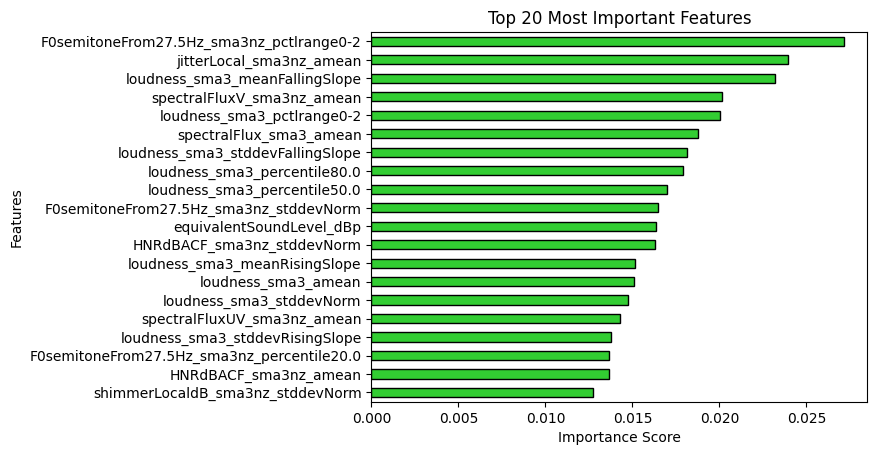

In [ ]:
pipeline.fit(X, y)

rf_model = pipeline.named_steps['rf']

importances = rf_model.feature_importances_
feature_names = X.columns

importance_series = pd.Series(importances, index=feature_names)

top_20_features = importance_series.sort_values(ascending=False).head(20)

top_20_features.sort_values(ascending=True).plot(kind='barh', color='limegreen', edgecolor='black')

plt.title('Top 20 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()